# Lab 2 — ML Primitives in NumPy

Run this notebook top to bottom as you build out `knn.py`, `gradient_descent.py`, and `pca.py` in this same folder. Each section below is a placeholder — see `Lab2_Instructions.md` for what belongs in each cell.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the data generation, plotting, and test calls are yours to write.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from knn import knn_predict, predict_grid, euclidean_distance, cosine_similarity, distances_to_all
from gradient_descent import f, grad_f, gradient_descent_1d, f2, grad_f2, gradient_descent_2d
from pca import pca_via_svd

## Part A: k-NN Classifier

In [3]:
# generating a small 2-class training set (X_train, y_train)
np.random.seed(0)
class_a = np.random.randn(30, 2) + np.array([2, 2])
class_b = np.random.randn(30, 2) + np.array([-2, -2])
X_train = np.vstack([class_a, class_b])
y_train = np.array([0] * 30 + [1] * 30)


In [ ]:
query = np.array([0.0, 0.0])
k = 5

# Sanity check: distances_to_all is euclidean_distance's formula reused via broadcasting, 
vectorized = distances_to_all(query, X_train)
scalar = np.array([euclidean_distance(query, row) for row in X_train])
assert np.allclose(vectorized, scalar), "distances_to_all disagrees with euclidean_distance"
print(f"distances_to_all matches euclidean_distance on all {len(X_train)} rows: OK")

# cosine_similarity from Step 1, exercised on the two class centroids (not on `query`, which is the zero vector and would trivially return 0.0 
# regardless of direction — a degenerate, uninformative case).
centroid_a = class_a.mean(axis=0)
centroid_b = class_b.mean(axis=0)
print(f"cosine_similarity(centroid_a, centroid_b) = {cosine_similarity(centroid_a, centroid_b):.4f}")

pred = knn_predict(query, X_train, y_train, k)
print(f"query {query} classified as class {pred} (k={k})")

distances_to_all matches euclidean_distance on all 60 rows: OK
cosine_similarity(centroid_a, centroid_b) = -0.9975
query [0. 0.] classified as class 1 (k=5)


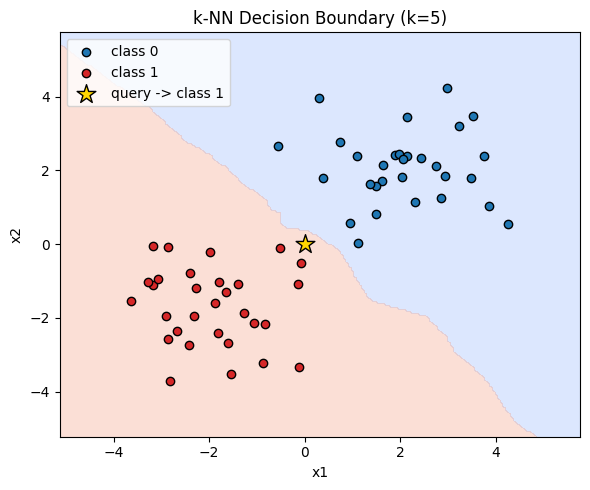

In [5]:
pad = 1.5
x_min, x_max = X_train[:, 0].min() - pad, X_train[:, 0].max() + pad
y_min, y_max = X_train[:, 1].min() - pad, X_train[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
zz = predict_grid(X_train, y_train, k, xx, yy)  # reshaped to xx.shape inside predict_grid

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, alpha=0.3, levels=1, cmap="coolwarm")
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c="tab:blue", label="class 0", edgecolor="k")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c="tab:red", label="class 1", edgecolor="k")
plt.scatter(*query, c="gold", marker="*", s=200, edgecolor="k",
            label=f"query -> class {pred}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"k-NN Decision Boundary (k={k})")
plt.legend()
plt.tight_layout()
plt.show()

## Part B: Gradient Descent

lr=0.05: final x=2.8728, final loss=0.0162
lr=0.5: final x=3.0000, final loss=0.0000
lr=1.05: final x=-49.3482, final loss=2740.3348


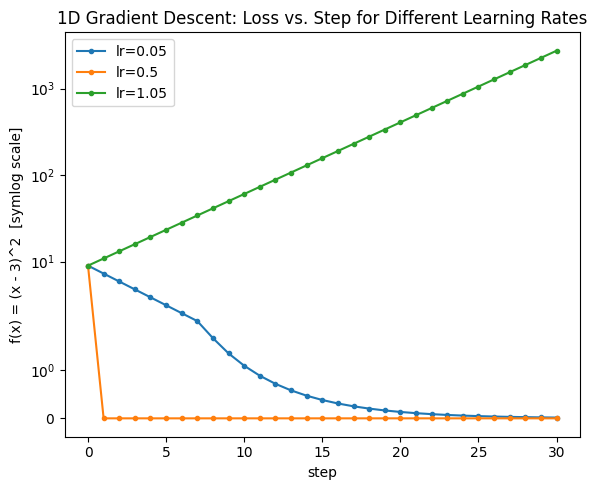

In [6]:
# 0.05: slow but safe, 0.5: near-ideal, 1.05: past the stable range (diverges)
learning_rates = [0.05, 0.5, 1.05]
steps = 30
start = 0.0

plt.figure(figsize=(6, 5))
for lr in learning_rates:
    final_x, history = gradient_descent_1d(start, lr, steps)
    losses = [f(x) for x in history]
    plt.plot(losses, marker="o", markersize=3, label=f"lr={lr}")
    print(f"lr={lr}: final x={final_x:.4f}, final loss={f(final_x):.4f}")

plt.yscale("symlog")  # the divergent lr blows up losses by orders of magnitude
plt.xlabel("step")
plt.ylabel("f(x) = (x - 3)^2  [symlog scale]")
plt.title("1D Gradient Descent: Loss vs. Step for Different Learning Rates")
plt.legend()
plt.tight_layout()
plt.show()

final point=[2.54672230e-06 2.72848411e-12], f2=0.0000


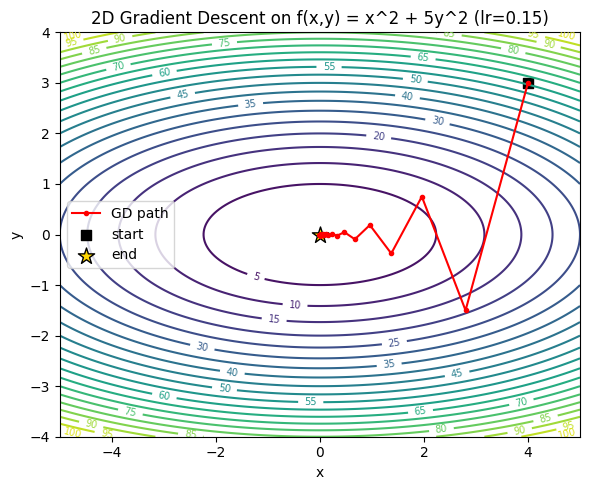

In [7]:
start_2d = np.array([4.0, 3.0])
lr_2d = 0.15
steps_2d = 40
final_point, path = gradient_descent_2d(start_2d, lr_2d, steps_2d)
print(f"final point={final_point}, f2={f2(*final_point):.4f}")

xg = np.linspace(-5, 5, 200)
yg = np.linspace(-4, 4, 200)
Xg, Yg = np.meshgrid(xg, yg)
Zg = f2(Xg, Yg)

plt.figure(figsize=(6, 5))
contours = plt.contour(Xg, Yg, Zg, levels=20, cmap="viridis")
plt.clabel(contours, inline=True, fontsize=7)
plt.plot(path[:, 0], path[:, 1], "-o", color="red", markersize=3, label="GD path")
plt.scatter(*start_2d, c="black", marker="s", s=60, label="start")
plt.scatter(*final_point, c="gold", marker="*", s=150, edgecolor="k", label="end")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"2D Gradient Descent on f(x,y) = x^2 + 5y^2 (lr={lr_2d})")
plt.legend()
plt.tight_layout()
plt.show()

## Part C: PCA Via SVD

In [8]:
n_pts = 200
x_pca = np.random.uniform(-5, 5, n_pts)
noise = np.random.normal(0, 1.5, n_pts)
y_pca = 2 * x_pca + noise
data = np.column_stack([x_pca, y_pca])

principal direction: [0.42363281 0.905834  ], mean: [-0.21449665 -0.56407396]


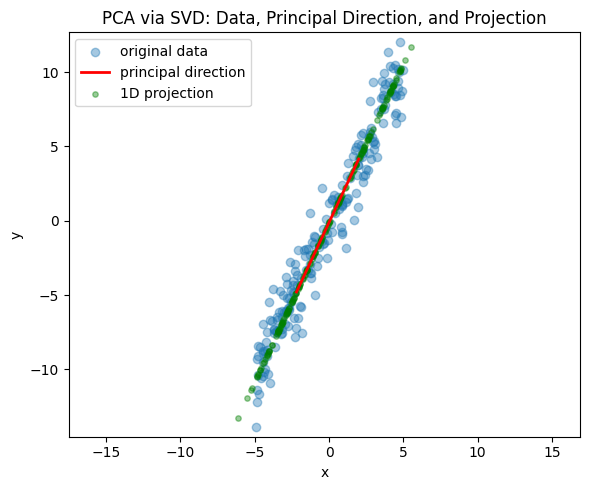

In [9]:
components, projected, mean = pca_via_svd(data, n_components=1)
pc1 = components[0]
print(f"principal direction: {pc1}, mean: {mean}")

reconstructed = projected @ components + mean  # 1D projection mapped back to 2D

centered = data - mean
t = np.linspace(centered[:, 0].min(), centered[:, 0].max(), 100)
line_pts = mean + np.outer(t, pc1)

plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], alpha=0.4, label="original data")
plt.plot(line_pts[:, 0], line_pts[:, 1], color="red", linewidth=2, label="principal direction")
plt.scatter(reconstructed[:, 0], reconstructed[:, 1], alpha=0.4, color="green", s=15, label="1D projection")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PCA via SVD: Data, Principal Direction, and Projection")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()